# Multimodel Models

By: Aveontae Frazier

In this notebook, I will explore the development of multimodel AI systems built on top of LLMs.

`Multimodel models` are AI systems capable of processing multiple data modelities as input or output (or both). `Multimodal (Large) Langauge Models` are multimodal models built on top of an LLM.

The core idea is that multimodel language models use LLMs as a core reasoning engine *because LLMs demonstrated a strong ability to acquire world knowledge.* Text prompts also enable 0-shot capabilities, i.e., using a model to perform a task it was never explicitly trained to complete. 

## Path 1: LLM + Tools
Adding external modules to do X-to-text or text-to-X

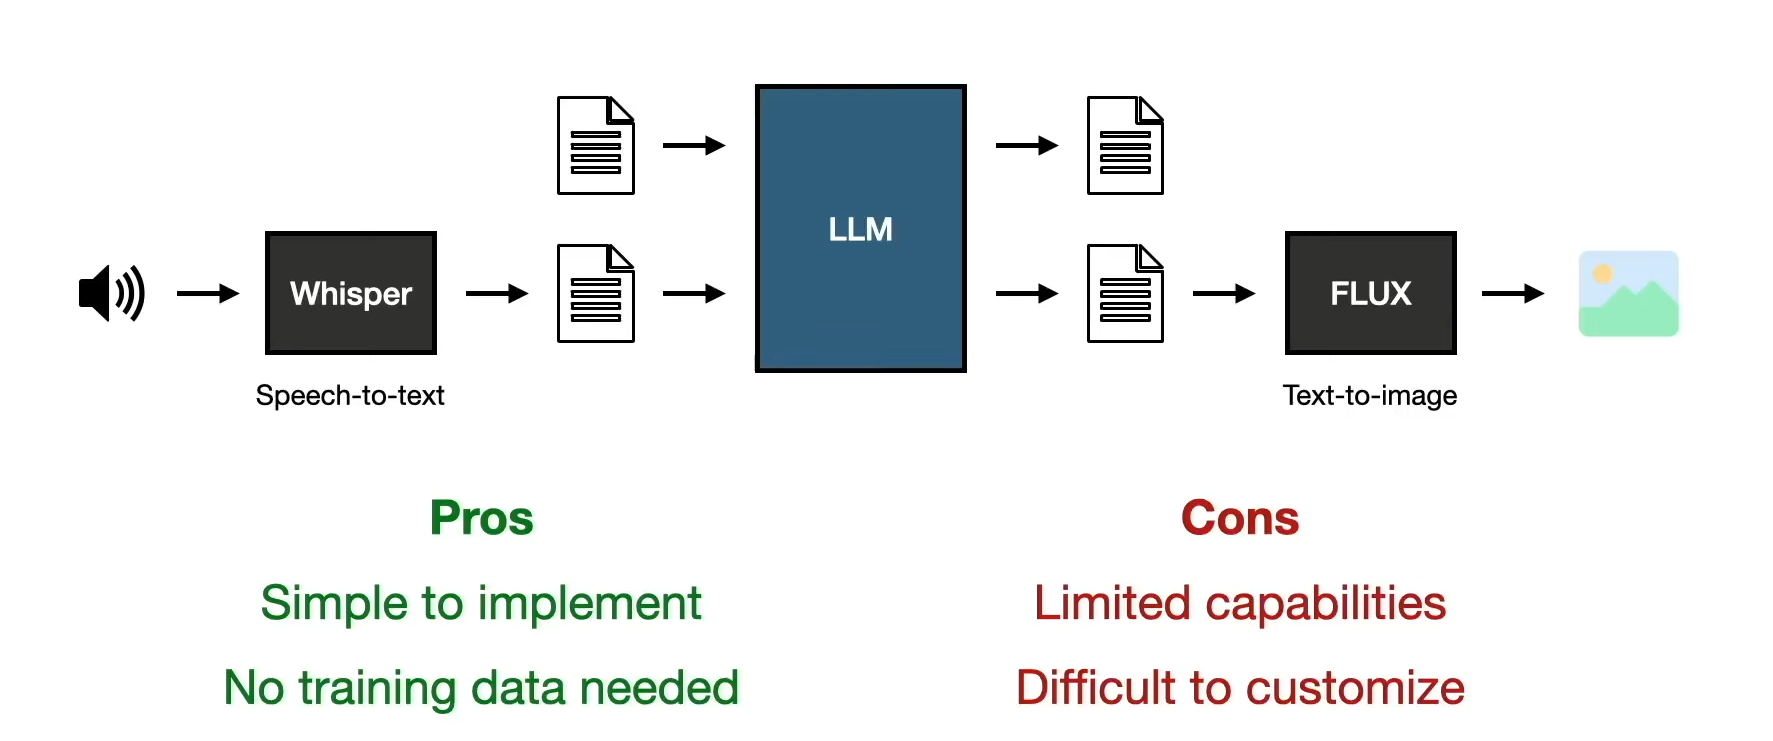

## Path 2: LLM + Adapters
Add encoders/decoders which are aligned via fine-tuning

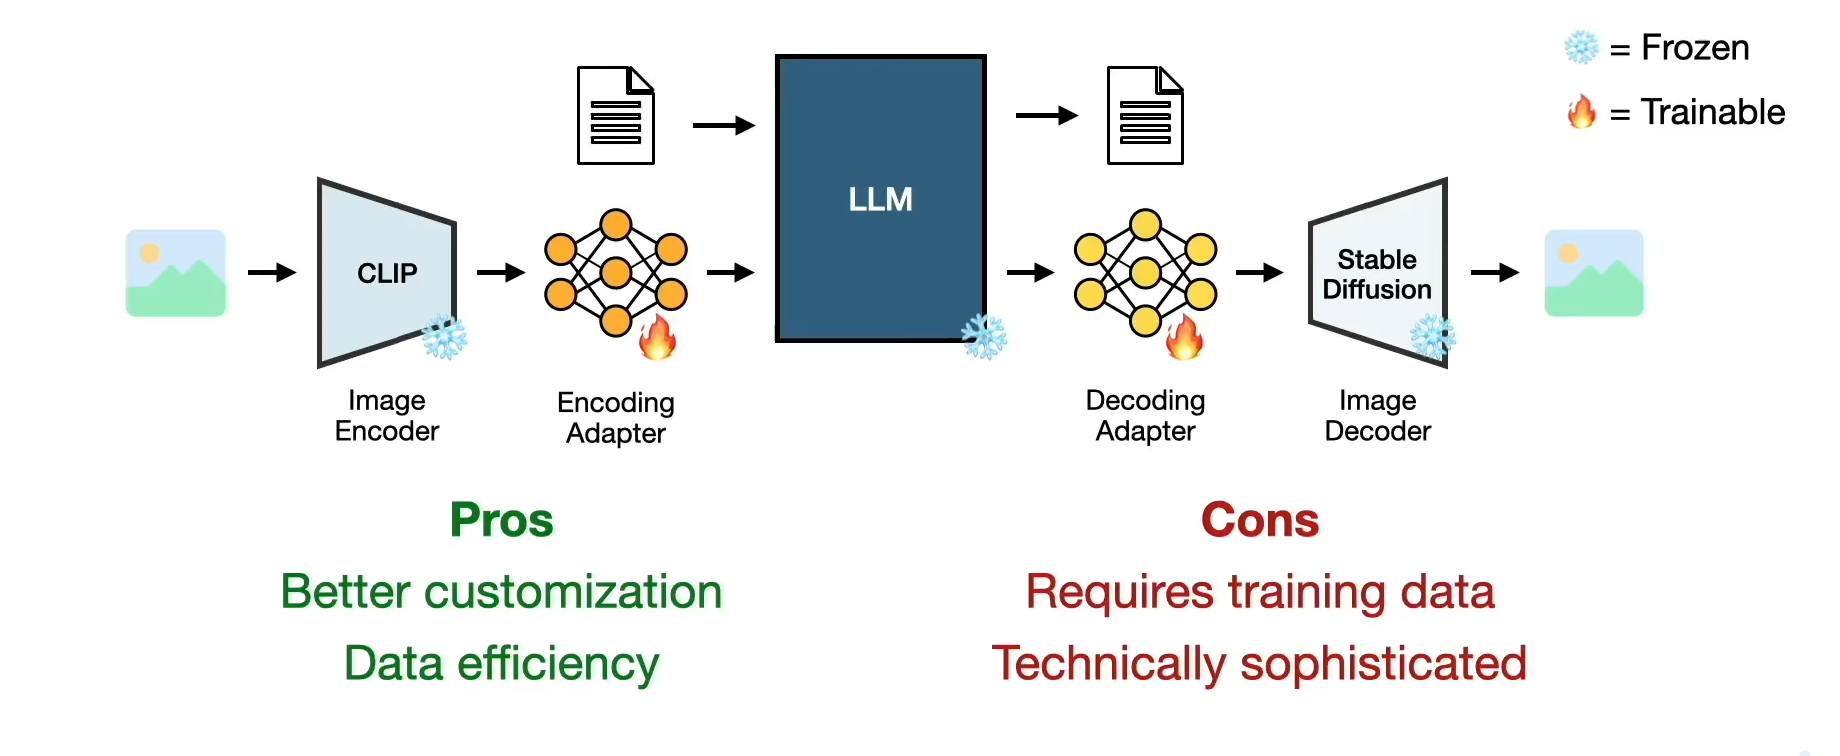

## Path 3: Unified Models
Mixing modalities at pre-training (i.e. training from scratch)

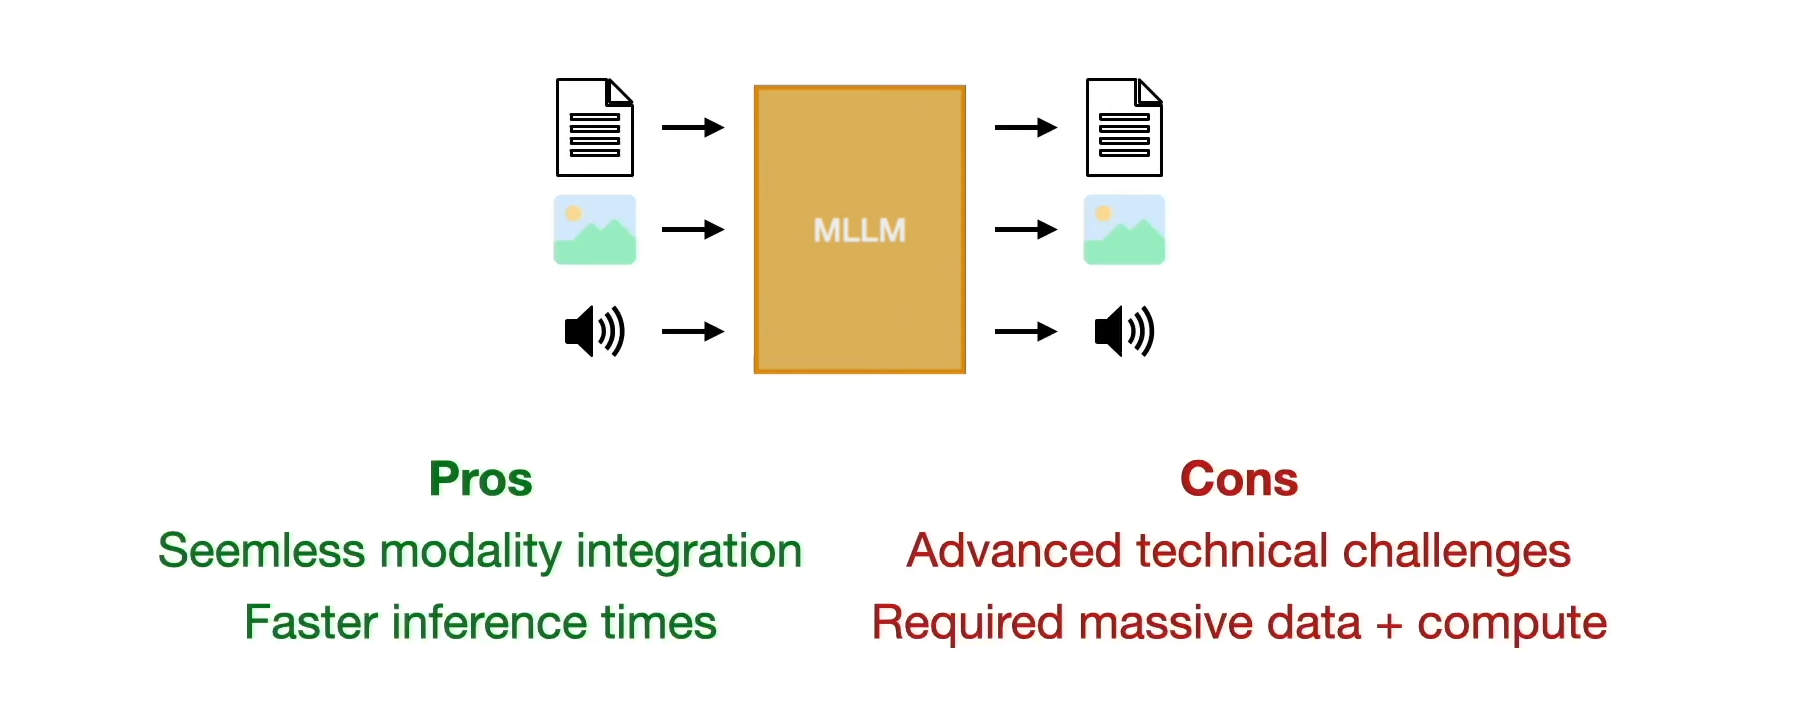

## LLaMA 3.2 Vision for Image-based Tasks

In [23]:
# Import mod
import ollama

## Pull Model

In [28]:
ollama.pull("llama3.2-vision") #11 Billion parameter version

ProgressResponse(status='success', completed=None, total=None, digest=None)

## Implementation

### Visual Question Answering

In [34]:
response = ollama.chat(
    model="llama3.2-vision",
    messages=[{
        "role": "user",
        "content": "What is in this image",
        "images": ["images/thena-and-i.jpg"]
    }]
)

print(response["message"]["content"]) # Nice! But the response took a long time to generate

The image shows a man crouched down on the sidewalk, with a dog standing next to him. The purpose of the image is to capture a moment between the two.

* A man:
	+ Crouched down on the sidewalk
	+ Wearing a red and blue plaid shirt
	+ Smiling and looking at the camera
* A dog:
	+ Standing next to the man
	+ White with brown spots
	+ Looking up at the man
* A street sign:
	+ In the background, behind the man and dog
	+ Not clearly visible

The image suggests that the man and dog are friends or companions, and they are enjoying each other's company on a sunny day.


### Streamlined

#### Visual Question Answering with Streaming Enabled
Respond one word at a time...

In [42]:
stream = ollama.chat(
    model="llama3.2-vision",
    messages=[{
        "role": "user",
        "content": "Can you write a caption for this image?",
        "images": ["images/glider.jpg"]
    }],
    stream=True
)

for chunk in stream: 
    print(chunk["message"]["content"], end="", flush=True)

The image depicts two individuals in a glider, with the vehicle's body painted white and featuring a blue lightning bolt design. The vehicle is labeled "U.S. AIR FORCE" on its side.

* A glider:
	+ Painted white
	+ Blue lightning bolt design
	+ Labeled "U.S. AIR FORCE" on the side
* Two people in the glider:
	+ Both wearing camouflage uniforms
	+ One person sitting at the front of the glider, possibly the pilot
	+ The other person sitting behind them, possibly a passenger or observer
* A mountain range in the background:
	+ Majestic and rugged terrain
	+ Snow-capped peaks visible

The image suggests that the individuals are engaged in some form of military training or operation, utilizing the glider as a mode of transportation or reconnaissance vehicle. The presence of the U.S. Air Force label on the glider reinforces this interpretation.

### Explaining memes

In [50]:
stream = ollama.chat(
    model="llama3.2-vision",
    messages=[{
        "role": "user",
        "content": "Can you explain this meme?",
        "images": ["images/meme.jpg"]
    }],
    stream=True
)

for chunk in stream:
    print(chunk["message"]["content"], end="", flush=True)

This meme features a man with a confused expression, accompanied by question marks above his head. The image is often used to convey confusion or disbelief in response to a statement or situation. It can be interpreted as "I don't understand" or "That's ridiculous." The meme has become popular on social media platforms such as Twitter and TikTok, where it is frequently used to react to humorous or absurd content.

### OCR

In [63]:
# summary

stream = ollama.chat(
    model="llama3.2-vision",
    messages=[{
        "role": "user", 
        "content": "Can you provide a detailed summary of this text in markdown?",
        "images": ["images/shipping-paper.png"]
    }],
    stream=True
)

for chunk in stream:
    print(chunk["message"]["content"], end="", flush=True)

**Whalemen's Shipping Paper**

The image presents a vintage shipping paper, specifically designed for Whalemen's use. The document is divided into sections with clear headings and concise language.

### Section 1: Agreement Details

* **Date:** Not specified
* **Name of Ship:** "WHALEMEN'S SHIPPING PAPER"
* **Port of Departure:** Not specified
* **Destination Port:** Not specified
* **Type of Vessel:** Whaler (implied by the title)

### Section 2: Agreement Terms

The agreement outlines the responsibilities and obligations of the ship's owner, master, seamen, and mariners. Key terms include:

* **Obligations of the Owner**
	+ Responsible for vessel maintenance
	+ Must provide necessary supplies
	+ Shall pay wages on time
* **Responsibilities of the Master**
	+ Command and control of the vessel
	+ Responsible for navigation and cargo handling
	+ Shall keep accurate records
* **Duties of Seamen and Mariners**
	+ Shall perform their duties diligently
	+ Shall obey orders from the master
	